In [4]:
import os, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
SEED = 42
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## Load & Clean

In [5]:
df = pd.read_csv('Credit_Card.csv', sep=';', on_bad_lines='skip', low_memory=False)

def _fix_dot_float(s):
    if pd.isna(s): return np.nan
    s = str(s).strip()
    if ',' in s:
        s = s.replace('.', '').replace(',', '.')
        try: return float(s)
        except: return np.nan
    parts = s.split('.')
    if len(parts) > 2:
        s = parts[0] + '.' + ''.join(parts[1:])
    try: return float(s)
    except: return np.nan

df['risk_leak'] = df['risk_leak'].apply(_fix_dot_float)
df['LIMIT_BAL_LOG'] = np.log(df['LIMIT_BAL'].clip(lower=1))

TARGET = 'default.payment.next.month'
PAY_COLS = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

## Task 1: EDA

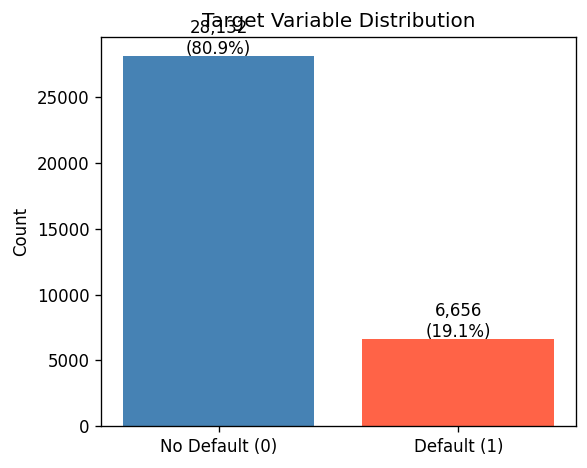

,mean,median,std,min,max
LIMIT_BAL,1.846690e+05,140000.000000,2.359319e+05,1.000000e+04,5.600000e+06
AGE,3.551830e+01,34.000000,9.236783e+00,2.100000e+01,7.900000e+01
BILL_AMT_SUM,2.948152e+05,129037.000000,5.718073e+05,-3.362590e+05,2.129266e+07
LIMIT_BAL_LOG,1.169820e+01,11.849398,9.671231e-01,9.210340e+00,1.553828e+01
risk_leak,-5.694061e+07,0.030655,5.113956e+09,-5.350000e+11,4.120000e+11


In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df[TARGET].value_counts()
ax.bar(['No Default (0)', 'Default (1)'], counts.values, color=['steelblue', 'tomato'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')
ax.set_title('Target Variable Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/01_target_distribution.png'); plt.show()

num_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'risk_leak']
desc = df[num_features].describe().T[['mean', '50%', 'std', 'min', 'max']]
desc.columns = ['mean', 'median', 'std', 'min', 'max']
desc.to_csv('outputs/descriptive_stats.csv')
desc

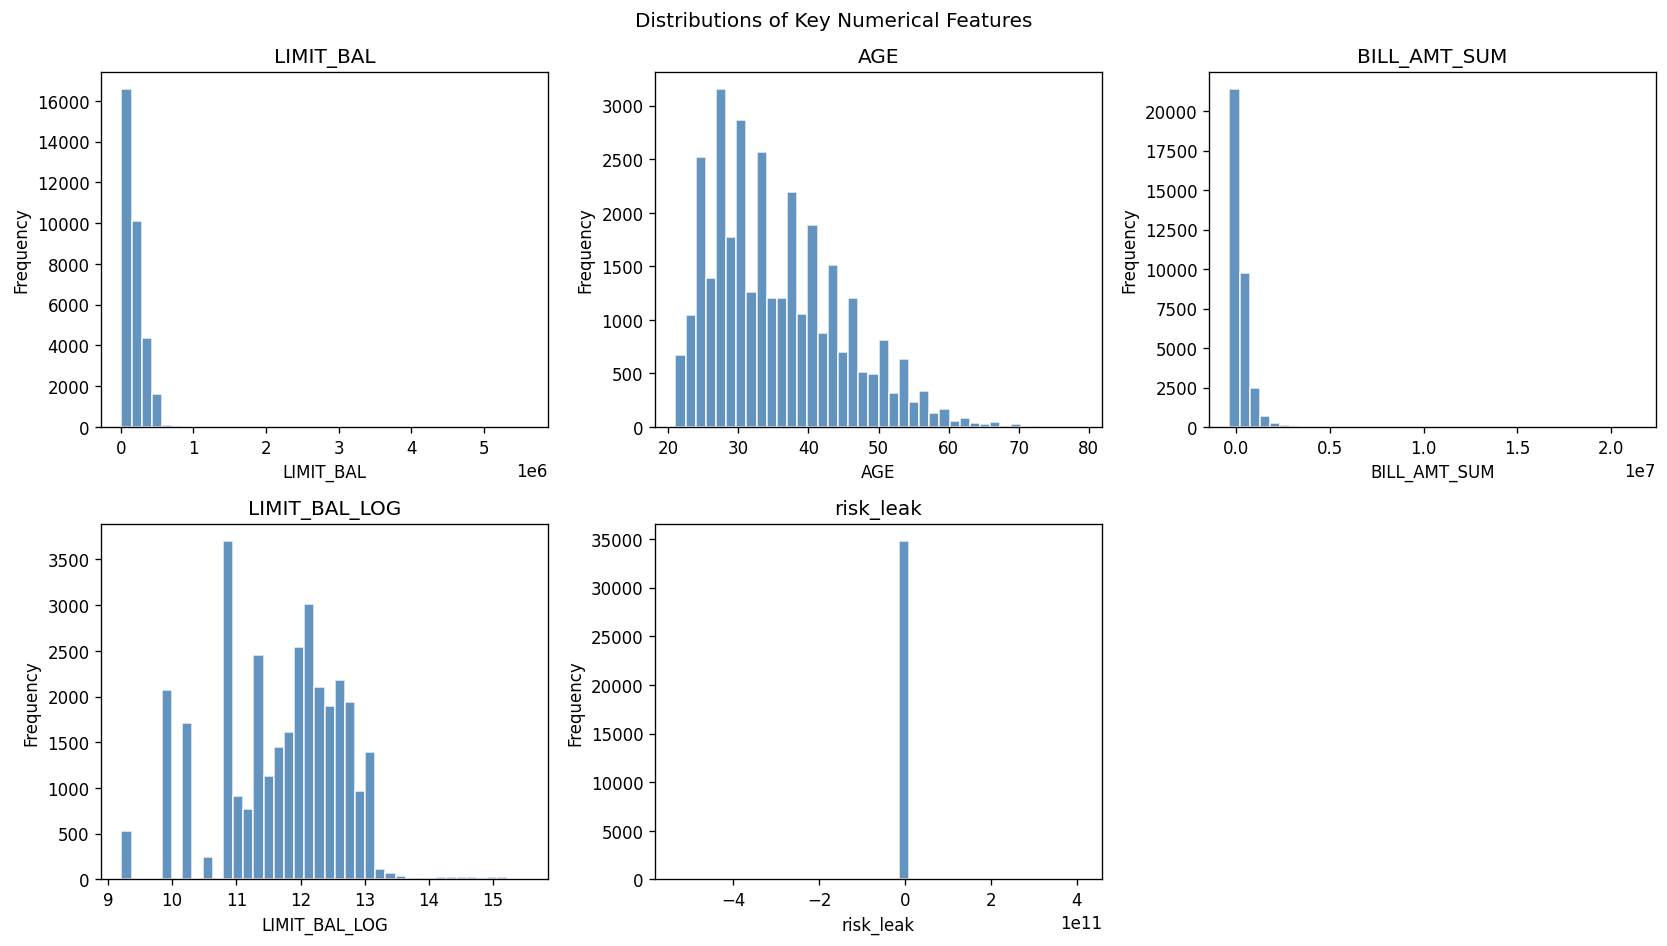

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(num_features):
    ax = axes[i // 3][i % 3]
    data = df[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel('Frequency')
axes[1][2].axis('off')
plt.suptitle('Distributions of Key Numerical Features', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/02_numeric_histograms.png'); plt.show()

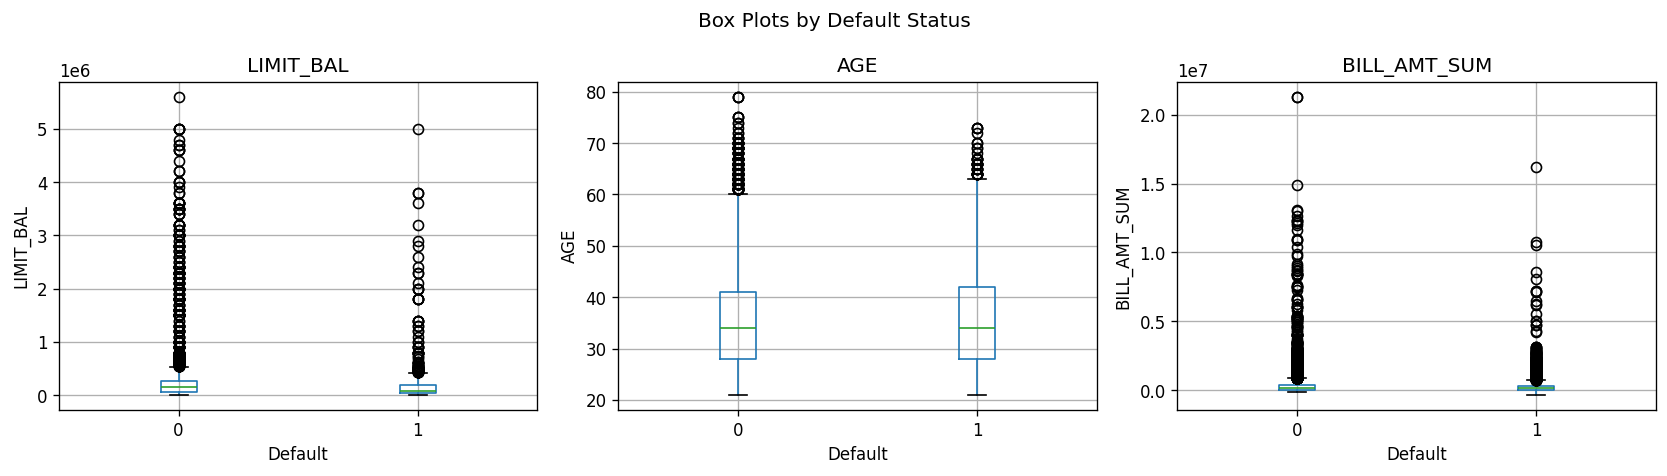

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM']):
    df.boxplot(column=col, by=TARGET, ax=ax)
    ax.set_title(col); ax.set_xlabel('Default'); ax.set_ylabel(col)
plt.suptitle('Box Plots by Default Status'); plt.tight_layout()
plt.savefig('outputs/03_boxplots_by_target.png'); plt.show()

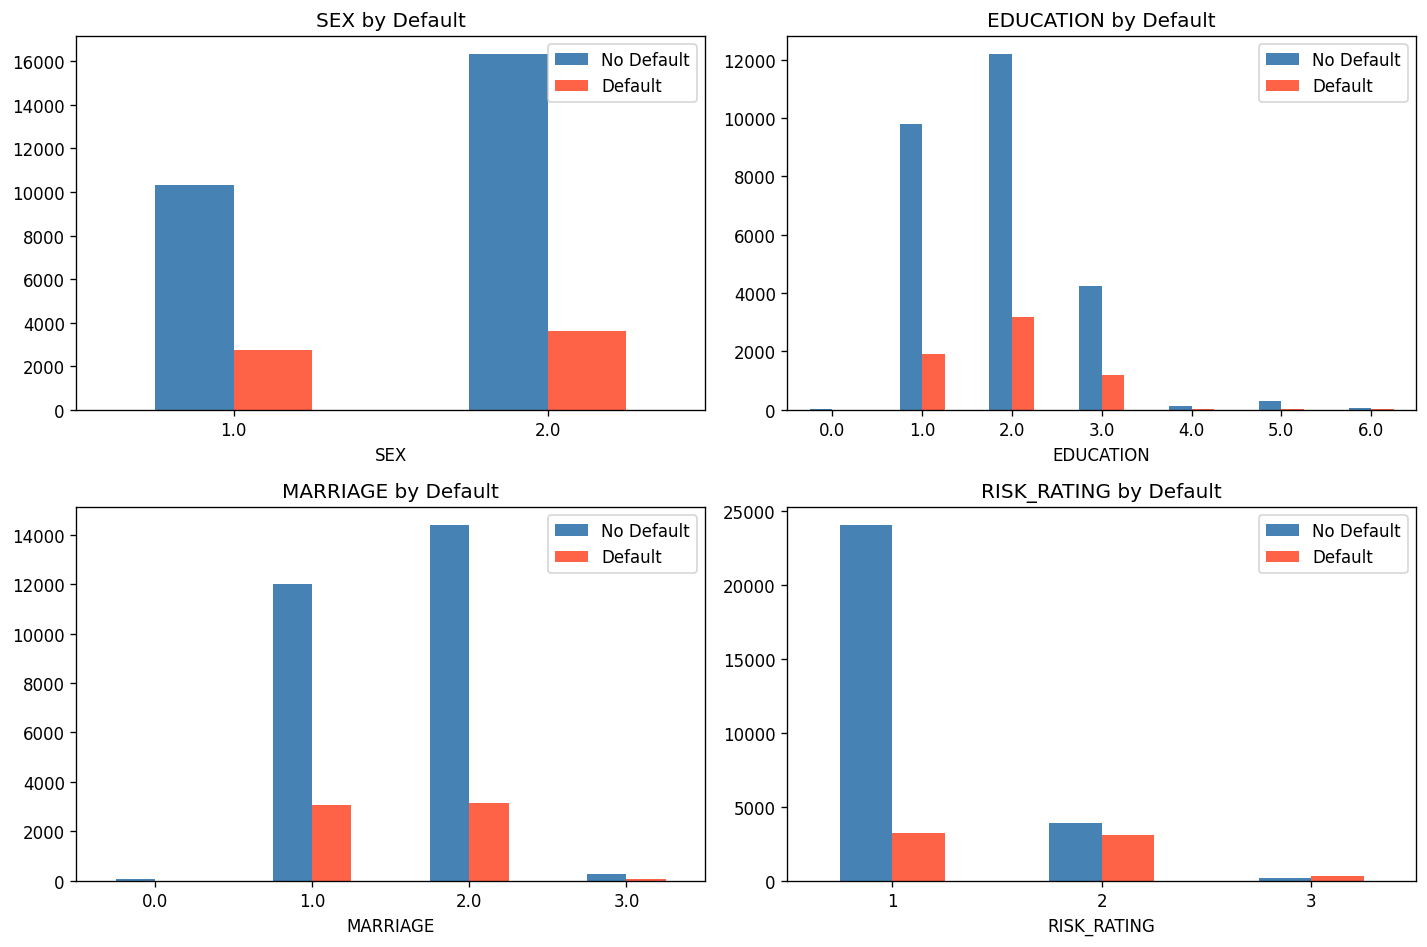

In [9]:
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'RISK_RATING']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    data = df.groupby([col, TARGET]).size().unstack(fill_value=0)
    data.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
    ax.set_title(f'{col} by Default'); ax.set_xlabel(col); ax.legend(['No Default', 'Default'])
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('outputs/04_categorical_distributions.png'); plt.show()

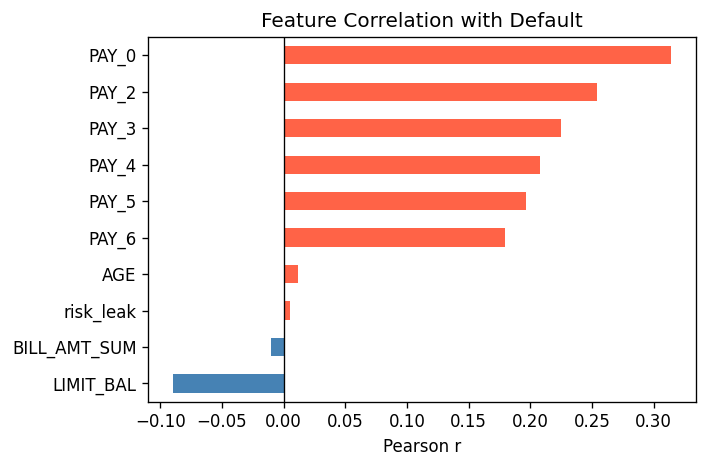

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
pay_corrs = df[PAY_COLS + ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'risk_leak']].corrwith(df[TARGET]).sort_values()
pay_corrs.plot(kind='barh', ax=ax, color=['tomato' if v > 0 else 'steelblue' for v in pay_corrs.values])
ax.set_title('Feature Correlation with Default'); ax.set_xlabel('Pearson r')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('outputs/05_feature_correlations.png'); plt.show()

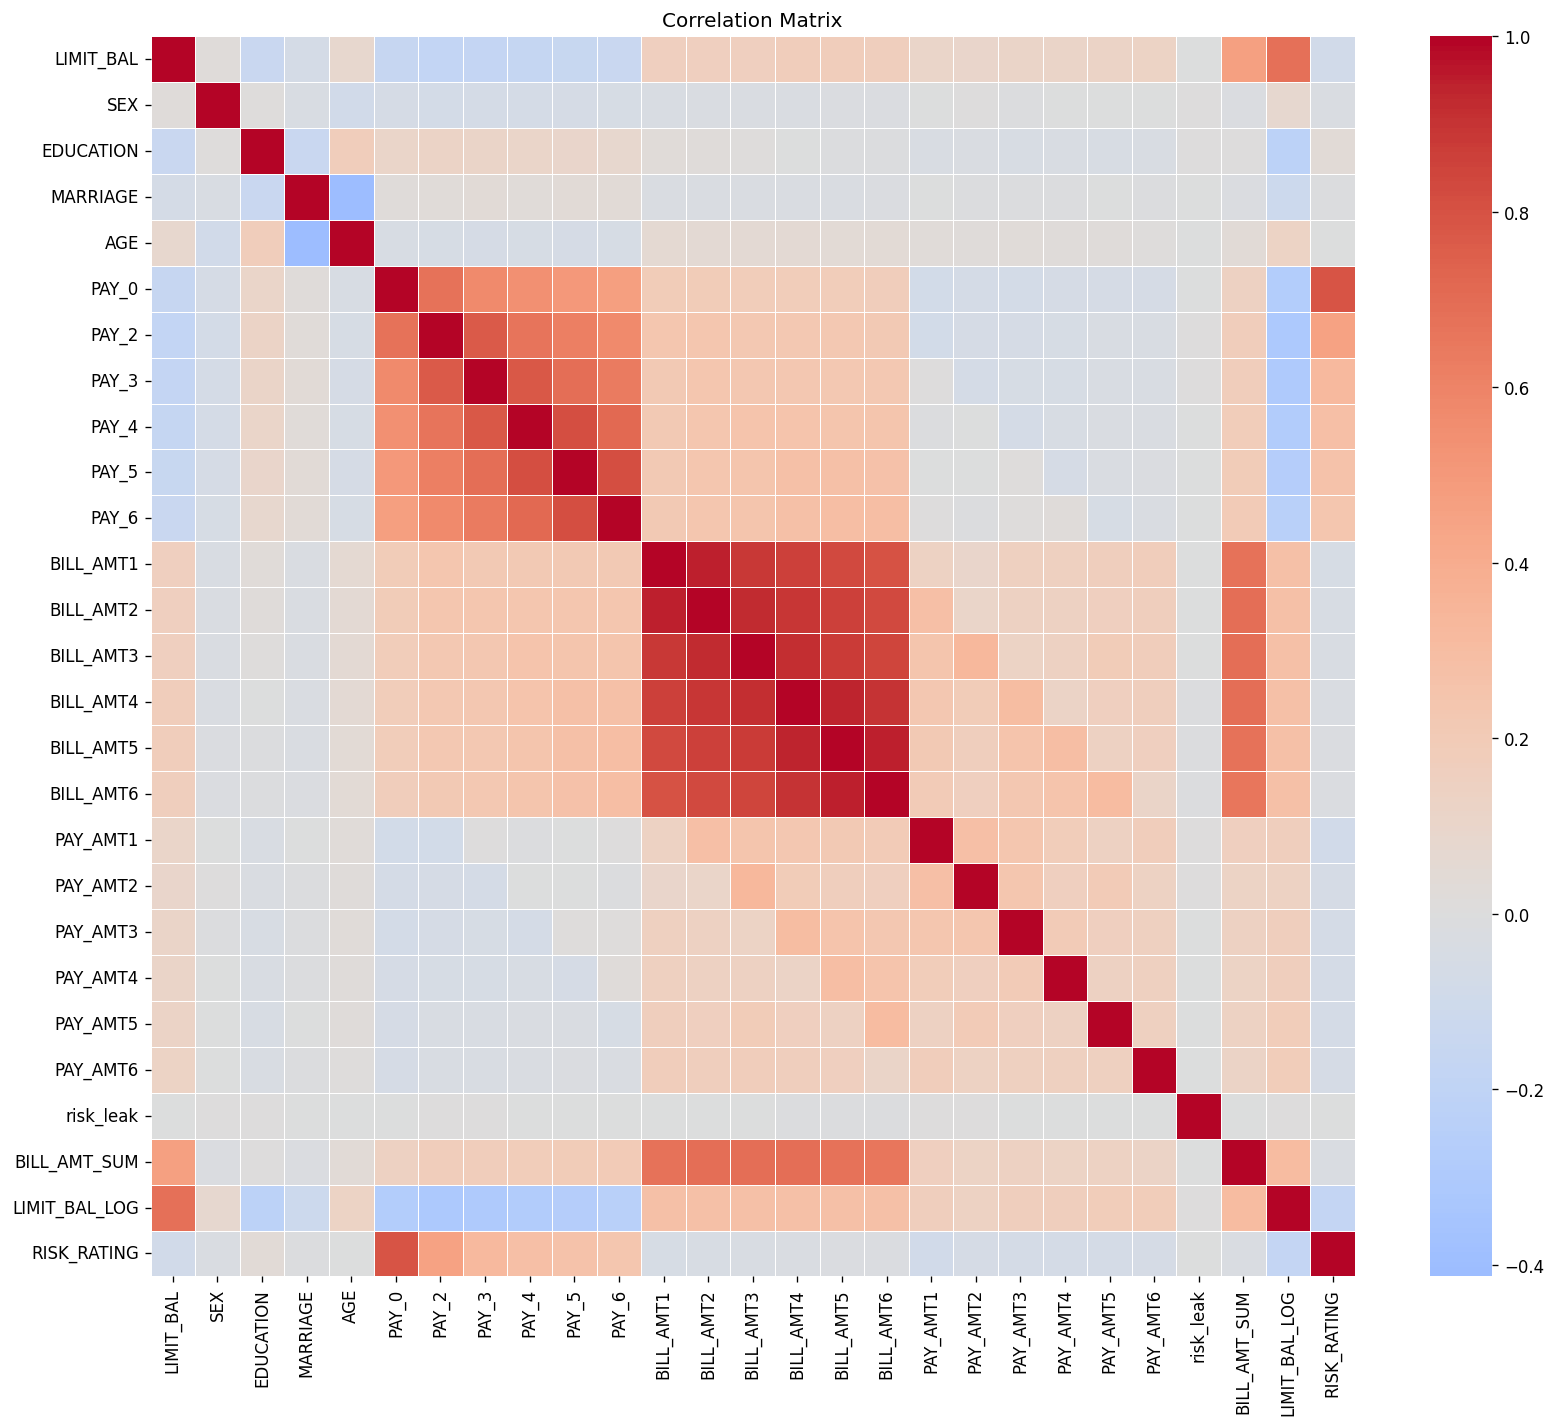

In [11]:
num_cols_all = df.select_dtypes(include=np.number).drop(columns=['ID', TARGET]).columns
corr_matrix = df[num_cols_all].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, ax=ax, cmap='coolwarm', center=0, linewidths=0.3, fmt='.1f', annot=False)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('outputs/06_correlation_heatmap.png'); plt.show()

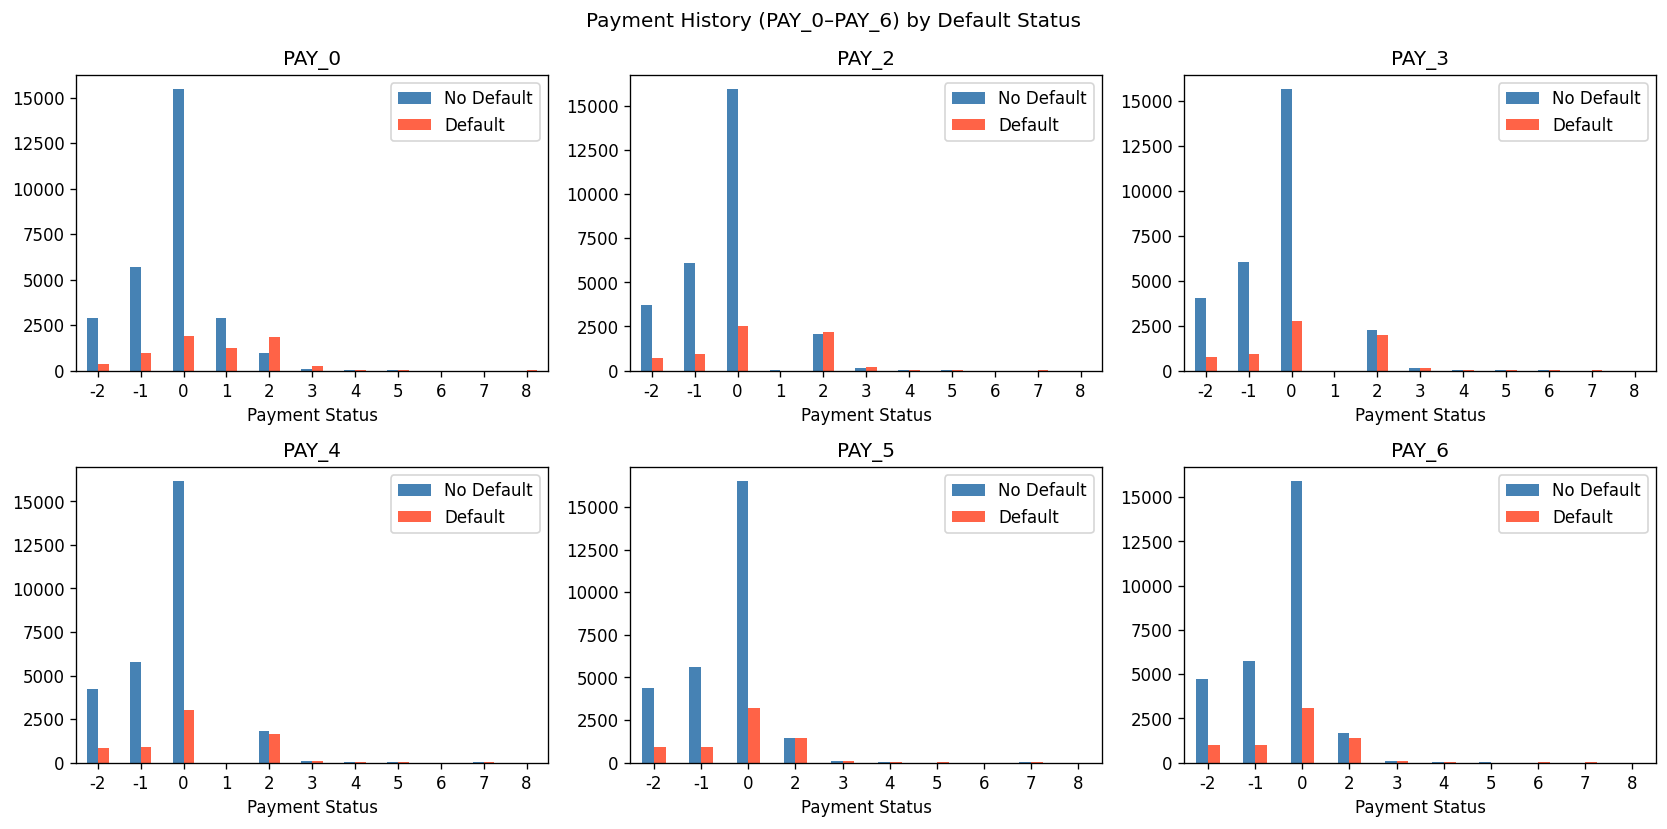

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), PAY_COLS):
    data = df.groupby([col, TARGET]).size().unstack(fill_value=0)
    data.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
    ax.set_title(col); ax.set_xlabel('Payment Status'); ax.legend(['No Default', 'Default'])
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Payment History (PAY_0–PAY_6) by Default Status')
plt.tight_layout()
plt.savefig('outputs/07_payment_history.png'); plt.show()

## Task 2: Data Preparation

In [13]:
missing_before = df.isnull().sum()[df.isnull().sum() > 0]
missing_before.to_csv('outputs/missing_values_before.csv')

drop_cols = ['ID', 'LIMIT_BAL_LOG', 'risk_leak']
df_model = df.drop(columns=drop_cols)
df_model['LIMIT_BAL_LOG'] = np.log(df_model['LIMIT_BAL'].clip(lower=1))

le = LabelEncoder()
df_model['CITY_ENC'] = le.fit_transform(df_model['CITY'].fillna('Unknown'))
df_model = df_model.drop(columns=['CITY'])

features = [c for c in df_model.columns if c != TARGET]
X = df_model[features]
y = df_model[TARGET]

num_cols = X.select_dtypes(include=np.number).columns.tolist()

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_proc = pd.DataFrame(scaler.fit_transform(imputer.fit_transform(X[num_cols])), columns=num_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_proc, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Target train dist: {dict(y_train.value_counts())}')

Train: (27830, 27), Test: (6958, 27)
Target train dist: {0: np.int64(22505), 1: np.int64(5325)}


## Task 3: Model Training

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=SEED),
    'SVM (Linear)': CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=SEED)),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=2, random_state=SEED),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED)
}

default_params = {name: model.get_params() for name, model in models.items()}
with open('outputs/default_hyperparameters.json', 'w') as f:
    json.dump({k: {p: str(v) for p, v in pars.items()} for k, pars in default_params.items()}, f, indent=2)

## Task 4: Evaluation & Visualisation

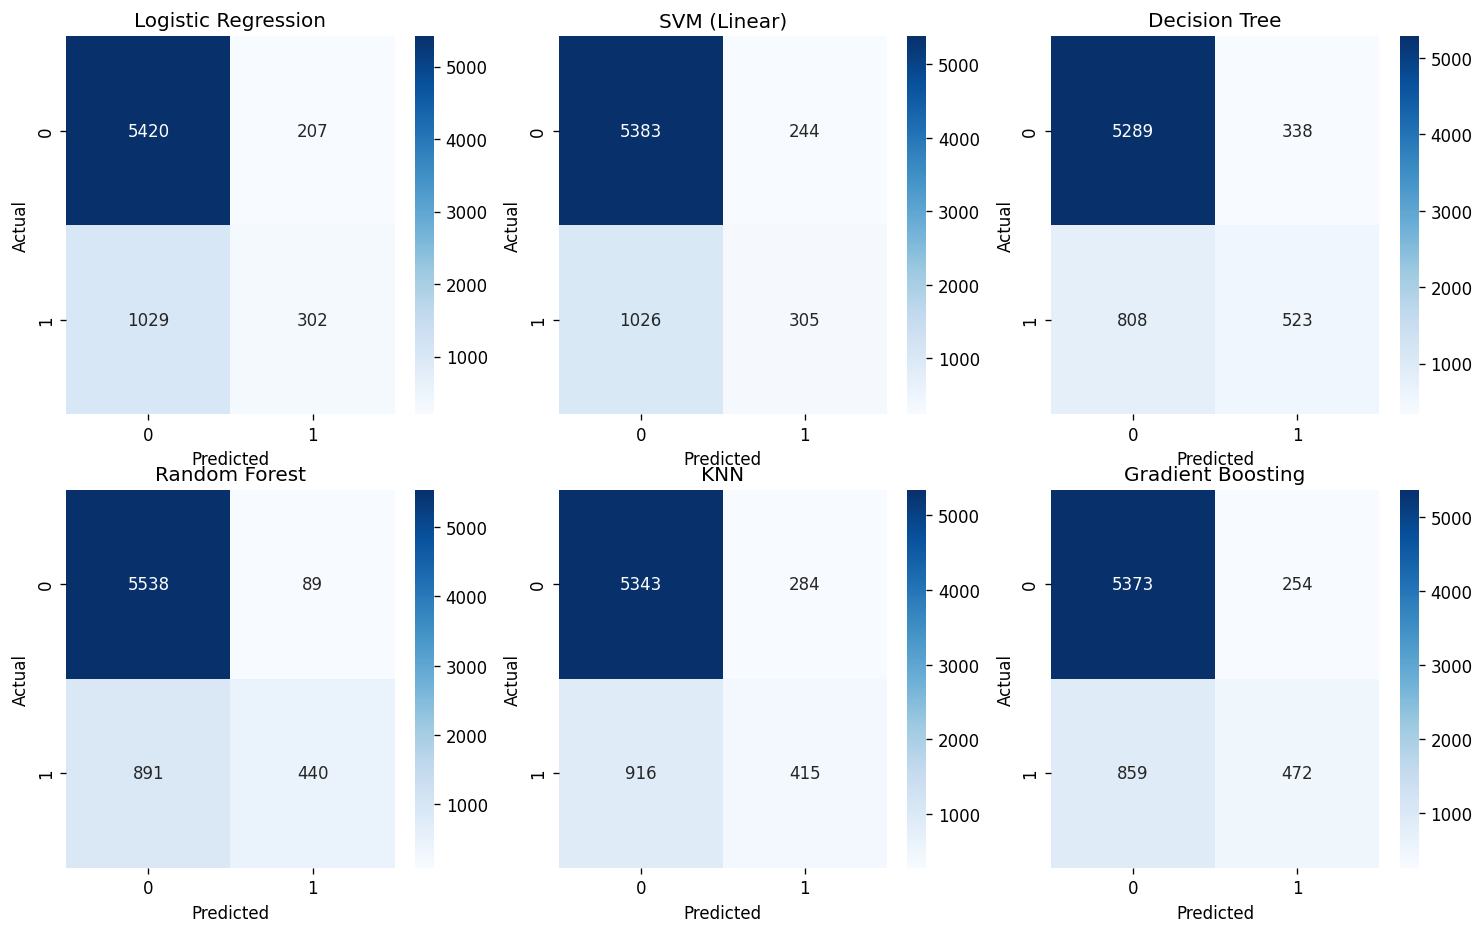

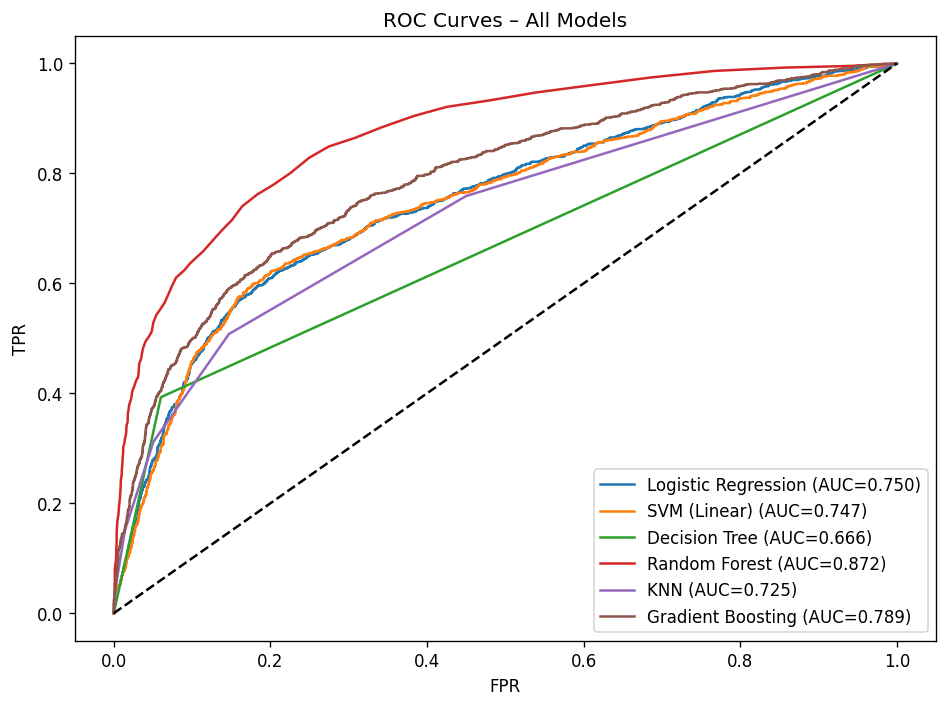


Model Comparison:
               Model  Accuracy  Precision  Recall     F1  AUC-ROC
      Random Forest    0.8592     0.8318  0.3306 0.4731   0.8721
  Gradient Boosting    0.8400     0.6501  0.3546 0.4589   0.7889
Logistic Regression    0.8224     0.5933  0.2269 0.3283   0.7501
       SVM (Linear)    0.8175     0.5556  0.2292 0.3245   0.7474
                KNN    0.8275     0.5937  0.3118 0.4089   0.7248
      Decision Tree    0.8353     0.6074  0.3929 0.4772   0.6664


In [15]:
results = []
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1': f1, 'AUC-ROC': auc})
    ax = axes_cm.flatten()[idx]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}'); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax_roc.plot([0, 1], [0, 1], 'k--')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC Curves – All Models'); ax_roc.legend(loc='lower right')
plt.tight_layout()
fig_roc.savefig('outputs/08_roc_curves.png'); plt.show()
fig_cm.tight_layout()
fig_cm.savefig('outputs/09_confusion_matrices.png'); plt.show()

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)
results_df.to_csv('outputs/model_comparison.csv', index=False)
print('\nModel Comparison:\n', results_df.round(4).to_string(index=False))

## Hyperparameter Tuning

In [ ]:
best_model_name = results_df.iloc[0]['Model']
print(f'\nTuning: {best_model_name}')

if best_model_name == 'Random Forest':
    param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20],
                  'min_samples_split': [2, 5]}
    base_model = RandomForestClassifier(random_state=SEED)
elif best_model_name == 'Gradient Boosting':
    param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5],
                  'learning_rate': [0.05, 0.1]}
    base_model = GradientBoostingClassifier(random_state=SEED)
else:
    param_grid = {'C': [0.1, 1, 10], 'max_iter': [200, 500]}
    base_model = LogisticRegression(random_state=SEED)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(base_model, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)
best_tuned = grid_search.best_estimator_

y_pred_tuned = best_tuned.predict(X_test)
y_prob_tuned = best_tuned.predict_proba(X_test)[:, 1]
tuned_result = {
    'Model': f'{best_model_name} (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned, zero_division=0),
    'Recall': recall_score(y_test, y_pred_tuned, zero_division=0),
    'F1': f1_score(y_test, y_pred_tuned, zero_division=0),
    'AUC-ROC': roc_auc_score(y_test, y_prob_tuned),
    'Best Params': str(grid_search.best_params_)
}
tuned_df = pd.DataFrame([tuned_result])
tuned_df.to_csv('outputs/tuned_model_results.csv', index=False)
print('Best params:', grid_search.best_params_)
print('Tuned AUC-ROC:', round(tuned_result['AUC-ROC'], 4))


Tuning: Random Forest


## Feature Importance / SHAP

In [ ]:
try:
    import shap
    explainer = shap.TreeExplainer(best_tuned)
    shap_values = explainer.shap_values(X_test[:500])
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    shap_df = pd.DataFrame({'feature': num_cols, 'mean_abs_shap': np.abs(sv).mean(axis=0)})
    shap_df = shap_df.sort_values('mean_abs_shap', ascending=False)
    shap_df.to_csv('outputs/shap_importance.csv', index=False)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(shap_df['feature'][:15][::-1], shap_df['mean_abs_shap'][:15][::-1], color='steelblue')
    ax.set_title(f'SHAP Feature Importance – {best_model_name} (Tuned)')
    ax.set_xlabel('Mean |SHAP value|')
    plt.tight_layout()
    plt.savefig('outputs/10_shap_importance.png'); plt.show()
    print('SHAP computed successfully.')
except Exception as e:
    print(f'SHAP unavailable ({e}), using permutation importance.')
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(best_tuned, X_test, y_test, n_repeats=10, random_state=SEED, scoring='roc_auc')
    imp_df = pd.DataFrame({'feature': num_cols, 'importance': perm.importances_mean})
    imp_df = imp_df.sort_values('importance', ascending=False)
    imp_df.to_csv('outputs/permutation_importance.csv', index=False)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(imp_df['feature'][:15][::-1], imp_df['importance'][:15][::-1], color='steelblue')
    ax.set_title(f'Permutation Importance – {best_model_name} (Tuned)')
    ax.set_xlabel('Mean decrease in AUC-ROC')
    plt.tight_layout()
    plt.savefig('outputs/10_feature_importance.png'); plt.show()

## Final Summary

In [ ]:
print('\n=== FINAL SUMMARY ===')
print(results_df[['Model', 'Accuracy', 'F1', 'AUC-ROC']].round(4).to_string(index=False))
print(f'\nBest model after tuning: {best_model_name}')
print(f'Tuned AUC-ROC: {tuned_result["AUC-ROC"]:.4f}')
print(f'Tuned F1:      {tuned_result["F1"]:.4f}')
print('\nAll outputs saved to outputs/')